<h1 style="color:magenta;">Exploración Inicial del Dataset 08 N-CMAPSS</h1>
<p> Valentina Arce España <p>
<p> Febrero 16, 2026 <p>
<p> Este set tiene todas las fallas.<p>

In [1]:
import os
import h5py
import time
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline

In [2]:
### Set-up - Define file location
filename = 'N-CMAPSS_DS08a-009.h5'

In [3]:
# Time tracking, Operation time (min):  0.003
t = time.process_time()  

# Load data
with h5py.File(filename, 'r') as hdf:
        # Development set
        W_dev = np.array(hdf.get('W_dev'))             # W
        X_s_dev = np.array(hdf.get('X_s_dev'))         # X_s
        X_v_dev = np.array(hdf.get('X_v_dev'))         # X_v
        T_dev = np.array(hdf.get('T_dev'))             # T
        Y_dev = np.array(hdf.get('Y_dev'))             # RUL  
        A_dev = np.array(hdf.get('A_dev'))             # Auxiliary

        # Test set
        W_test = np.array(hdf.get('W_test'))           # W
        X_s_test = np.array(hdf.get('X_s_test'))       # X_s
        X_v_test = np.array(hdf.get('X_v_test'))       # X_v
        T_test = np.array(hdf.get('T_test'))           # T
        Y_test = np.array(hdf.get('Y_test'))           # RUL  
        A_test = np.array(hdf.get('A_test'))           # Auxiliary
        
        # Varnams
        W_var = np.array(hdf.get('W_var'))
        X_s_var = np.array(hdf.get('X_s_var'))  
        X_v_var = np.array(hdf.get('X_v_var')) 
        T_var = np.array(hdf.get('T_var'))
        A_var = np.array(hdf.get('A_var'))
        
        # from np.array to list dtype U4/U5
        W_var = list(np.array(W_var, dtype='U20'))
        X_s_var = list(np.array(X_s_var, dtype='U20'))  
        X_v_var = list(np.array(X_v_var, dtype='U20')) 
        T_var = list(np.array(T_var, dtype='U20'))
        A_var = list(np.array(A_var, dtype='U20'))
                          
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))


Operation time (min):  0.16541573333333334

W shape: (8608386, 4)
X_s shape: (8608386, 14)
X_v shape: (8608386, 14)
T shape: (8608386, 10)
A shape: (8608386, 4)


In [4]:
df_A = DataFrame(data=A, columns=A_var)
df_A.describe()

,unit,cycle,Fc,hs
count,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06
mean,8.344847e+00,3.213738e+01,2.276348e+00,3.076789e-01
std,4.235085e+00,1.928259e+01,7.718417e-01,4.615329e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,5.000000e+00,1.600000e+01,2.000000e+00,0.000000e+00
50%,8.000000e+00,3.100000e+01,2.000000e+00,0.000000e+00
75%,1.200000e+01,4.700000e+01,3.000000e+00,1.000000e+00
max,1.500000e+01,9.500000e+01,3.000000e+00,1.000000e+00


In [5]:
df_T = DataFrame(data=T, columns=T_var)
df_T.describe()

,fan_eff_mod,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod
count,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06,8.608386e+06
mean,-2.320698e-03,-3.285691e-03,-2.805334e-03,-3.591076e-03,-1.988013e-03,-3.084773e-03,-2.040594e-03,-3.092808e-03,-2.209965e-03,-3.334201e-03
std,3.016219e-03,4.897674e-03,5.157783e-03,5.460270e-03,2.220648e-03,4.061802e-03,2.110078e-03,4.456321e-03,2.820448e-03,4.758706e-03
min,-2.794594e-02,-5.310735e-02,-6.134329e-02,-4.618675e-02,-2.553976e-02,-3.595611e-02,-1.553917e-02,-3.890806e-02,-2.995698e-02,-3.901896e-02
25%,-2.622948e-03,-3.781142e-03,-2.720273e-03,-3.998872e-03,-2.388913e-03,-3.729434e-03,-2.492416e-03,-3.902601e-03,-2.407419e-03,-3.765746e-03
50%,-1.275920e-03,-1.492651e-03,-1.449952e-03,-1.521547e-03,-1.241043e-03,-1.474622e-03,-1.278113e-03,-1.370324e-03,-1.411879e-03,-1.512258e-03
75%,-8.045645e-04,-8.824126e-04,-8.809012e-04,-9.321179e-04,-7.837716e-04,-9.823424e-04,-8.085162e-04,-6.517589e-04,-9.536589e-04,-8.240822e-04
max,1.243731e-05,-3.214966e-06,-2.100859e-05,1.279831e-04,1.419144e-04,-5.741187e-06,-3.501375e-05,1.104734e-04,1.705489e-05,-7.866245e-05


In [6]:
print('Engine units in df: ', np.unique(df_A['unit']))

Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


Text(0, 0.5, 'Flight Class # [-]')

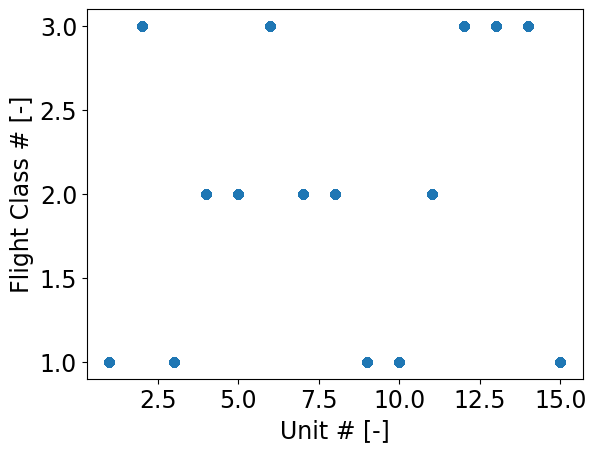

In [7]:
labelsize = 17
plt.plot(df_A.unit, df_A.Fc, 'o')
plt.tick_params(axis='x', labelsize=labelsize )
plt.tick_params(axis='y', labelsize=labelsize )
plt.xlabel('Unit # [-]', fontsize=labelsize)
plt.ylabel('Flight Class # [-]', fontsize=labelsize )

In [8]:
for i in np.unique(df_A['unit']):
    print('Unit: ' + str(i) + ' - Number of flight cyles (t_{EOF}): ', len(np.unique(df_A.loc[df_A['unit'] == i, 'cycle'])))
    #np.unique(df_A.loc[df_A['unit'] == i, 'cycle'])

Unit: 1.0 - Number of flight cyles (t_{EOF}):  72
Unit: 2.0 - Number of flight cyles (t_{EOF}):  51
Unit: 3.0 - Number of flight cyles (t_{EOF}):  75
Unit: 4.0 - Number of flight cyles (t_{EOF}):  71
Unit: 5.0 - Number of flight cyles (t_{EOF}):  56
Unit: 6.0 - Number of flight cyles (t_{EOF}):  58
Unit: 7.0 - Number of flight cyles (t_{EOF}):  68
Unit: 8.0 - Number of flight cyles (t_{EOF}):  65
Unit: 9.0 - Number of flight cyles (t_{EOF}):  95
Unit: 10.0 - Number of flight cyles (t_{EOF}):  78
Unit: 11.0 - Number of flight cyles (t_{EOF}):  60
Unit: 12.0 - Number of flight cyles (t_{EOF}):  58
Unit: 13.0 - Number of flight cyles (t_{EOF}):  56
Unit: 14.0 - Number of flight cyles (t_{EOF}):  59
Unit: 15.0 - Number of flight cyles (t_{EOF}):  72


In [9]:
df_W = DataFrame(data=W, columns=W_var)
df_W['unit'] = df_A['unit'].values

In [10]:
def plot_df_single_color(data, variables, labels, size=12, labelsize=17, name=None):
    """
    """
    plt.clf()        
    input_dim = len(variables)
    cols = min(np.floor(input_dim**0.5).astype(int),4)
    rows = (np.ceil(input_dim / cols)).astype(int)
    gs   = gridspec.GridSpec(rows, cols)    
    fig  = plt.figure(figsize=(size,max(size,rows*2))) 
    
    for n in range(input_dim):
        ax = fig.add_subplot(gs[n])
        ax.plot(data[variables[n]], marker='.', markerfacecolor='none', alpha = 0.7)
        ax.tick_params(axis='x', labelsize=labelsize)
        ax.tick_params(axis='y', labelsize=labelsize)
        plt.ylabel(labels[n], fontsize=labelsize)
        plt.xlabel('Time [s]', fontsize=labelsize)
    plt.tight_layout()
    if name is not None:
        plt.savefig(name, format='png', dpi=300)   
    plt.show()
    plt.close()

In [11]:
def plot_df_color_per_unit(data, variables, labels, size=7, labelsize=17, option='Time', name=None):
    """
    """
    plt.clf()        
    input_dim = len(variables)
    cols = min(np.floor(input_dim**0.5).astype(int),4)
    rows = (np.ceil(input_dim / cols)).astype(int)
    gs   = gridspec.GridSpec(rows, cols)
    leg  = []
    fig  = plt.figure(figsize=(size,max(size,rows*2)))
    color_dic_unit = {'Unit 1': 'C0', 'Unit 2': 'C1', 'Unit 3': 'C2', 'Unit 4': 'C3', 'Unit 5': 'C4', 'Unit 6': 'C5',
                      'Unit 7': 'C6', 'Unit 8': 'C7', 'Unit 9': 'C8', 'Unit 10': 'C9', 'Unit 11': 'C10',
                      'Unit 12': 'C11', 'Unit 13': 'C12', 'Unit 14': 'C13', 'Unit 15': 'C14', 'Unit 16': 'C15',
                      'Unit 17': 'C16', 'Unit 18': 'C17', 'Unit 19': 'C18', 'Unit 20': 'C19'} 
    
    unit_sel  = np.unique(data['unit'])
    for n in range(input_dim):
        ax = fig.add_subplot(gs[n])
        for j in unit_sel:
            data_unit = data.loc[data['unit'] == j]
            if option=='cycle':
                time_s = data.loc[data['unit'] == j, 'cycle']
                label_x = 'Time [cycle]'
            else:
                time_s = np.arange(len(data_unit))
                label_x = 'Time [s]'
            ax.plot(time_s, data_unit[variables[n]], '-o', color=color_dic_unit['Unit ' + str(int(j))],
                    alpha=0.7, markersize=5)
            ax.tick_params(axis='x', labelsize=labelsize)
            ax.tick_params(axis='y', labelsize=labelsize)
            leg.append('Unit '+str(int(j)))
        plt.ylabel(labels[n], fontsize=labelsize)    
        plt.xlabel(label_x, fontsize=labelsize)
        ax.get_xaxis().set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
        if n==0:
            ax.get_yaxis().set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.legend(leg, loc='best', fontsize=labelsize-2) #lower left
    plt.tight_layout()
    if name is not None:
        plt.savefig(name, format='png', dpi=300)   
    plt.show()
    plt.close()

<Figure size 640x480 with 0 Axes>

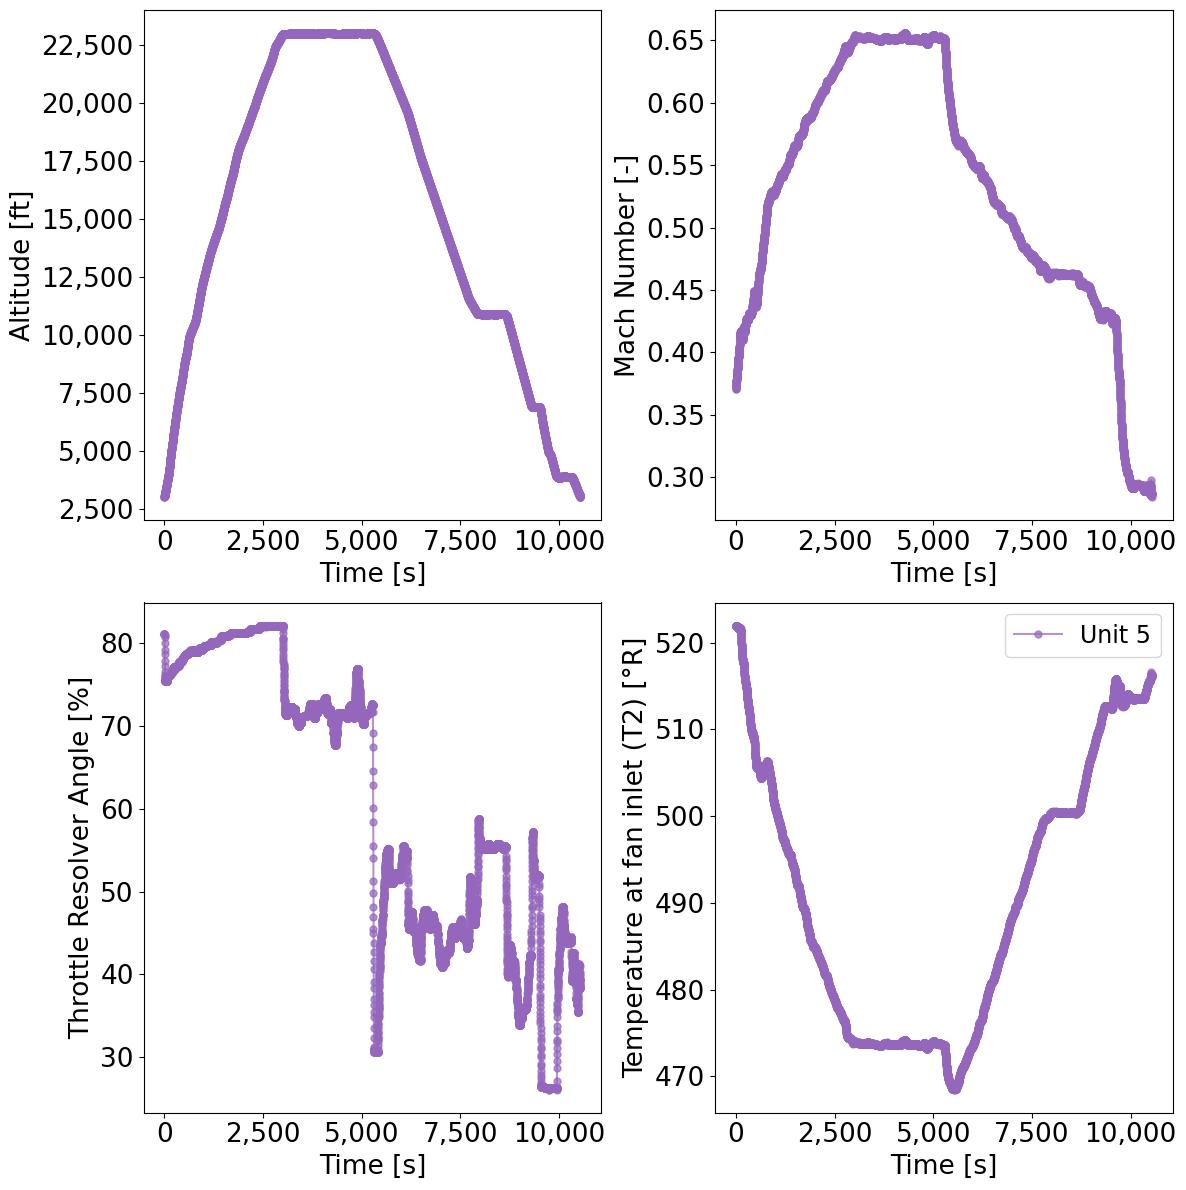

In [12]:
df_W_u = df_W.loc[(df_A.unit == 5) & (df_A.cycle == 1)]
df_W_u.reset_index(inplace=True, drop=True)
labels = ['Altitude [ft]', 'Mach Number [-]', 'Throttle Resolver Angle [%]', 'Temperature at fan inlet (T2) [°R]']
plot_df_color_per_unit(df_W_u, W_var , labels, size=12, labelsize=19, name='flight_profile_DS02.png')

Text(0, 0.5, 'Flight Altitude - [ft]')

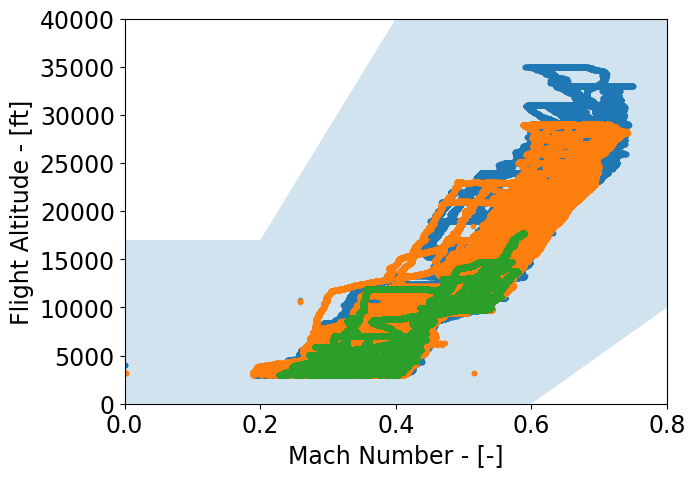

In [13]:
labelsize = 17
x = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
u = np.array([1.7, 1.7, 4.0, 4.0, 4.0])*10000
l = np.array([0.0, 0.0, 0.0, 0.0, 1.0])*10000
plt.figure(figsize=(7,5)) 
plt.fill_between(x, l, u, alpha=0.2)
plt.plot(df_W.loc[df_A['Fc'] == 3, 'Mach'], df_W.loc[df_A['Fc'] == 3, 'alt'], '.', alpha=0.9)
plt.plot(df_W.loc[df_A['Fc'] == 2, 'Mach'], df_W.loc[df_A['Fc'] == 2, 'alt'], '.', alpha=0.9)
plt.plot(df_W.loc[df_A['Fc'] == 1, 'Mach'], df_W.loc[df_A['Fc'] == 1, 'alt'], '.', alpha=0.9)
plt.tick_params(axis='x', labelsize=labelsize )
plt.tick_params(axis='y', labelsize=labelsize )
plt.xlim((0.0, 0.8))
plt.ylim((0, 40000)) 
plt.xlabel('Mach Number - [-]', fontsize=labelsize)
plt.ylabel('Flight Altitude - [ft]', fontsize=labelsize)

In [14]:
def plot_kde(leg, variables, labels, size, units, df_W, df_A, labelsize=17, name=None):
    """
    """
    plt.clf()
       
    input_dim = len(variables)
    cols = min(np.floor(input_dim**0.5).astype(int),4)
    rows = (np.ceil(input_dim / cols)).astype(int)
    gs = gridspec.GridSpec(rows, cols)
    
    color_dic_unit = {'Unit 1': 'C0', 'Unit 2': 'C1', 'Unit 3': 'C2', 'Unit 4': 'C3', 'Unit 5': 'C4', 'Unit 6': 'C5',
                      'Unit 7': 'C6', 'Unit 8': 'C7', 'Unit 9': 'C8', 'Unit 10': 'C9', 'Unit 11': 'C10',
                      'Unit 12': 'C11', 'Unit 13': 'C12', 'Unit 14': 'C13', 'Unit 15': 'C14', 'Unit 16': 'C15',
                      'Unit 17': 'C16', 'Unit 18': 'C17', 'Unit 19': 'C18', 'Unit 20': 'C19'} 
    
    fig = plt.figure(figsize=(size,max(size,rows*2)))       

    for n in range(input_dim):
        ax = fig.add_subplot(gs[n])
        for k, elem in enumerate(units):
            sns.kdeplot(df_W.loc[df_A['unit'] == elem, variables[n]],
                        color=color_dic_unit[leg[k]], shade=True, gridsize=100)  
            ax.tick_params(axis='x', labelsize=labelsize)
            ax.tick_params(axis='y', labelsize=labelsize)
        
        ax.get_xaxis().set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))        
        plt.xlabel(labels[n], fontsize=labelsize)
        plt.ylabel('Density [-]', fontsize=labelsize)
        if n==0:
            plt.legend(leg, fontsize=labelsize-4, loc=0)
        else:
            plt.legend(leg, fontsize=labelsize-4, loc=2)
    plt.tight_layout()
    if name is not None:
        plt.savefig(name, format='png', dpi=300)    
    plt.show()
    plt.close()

/var/folders/62/k3ln0yrn33jbx5j8wr7ynf5c0000gn/T/ipykernel_4268/4172860585.py:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_W.loc[df_A['unit'] == elem, variables[n]],
/var/folders/62/k3ln0yrn33jbx5j8wr7ynf5c0000gn/T/ipykernel_4268/4172860585.py:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_W.loc[df_A['unit'] == elem, variables[n]],
/var/folders/62/k3ln0yrn33jbx5j8wr7ynf5c0000gn/T/ipykernel_4268/4172860585.py:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_W.loc[df_A['unit'] == elem, variables[n]],
/var/folders/62/k3ln0yrn33jbx5j8wr7ynf5c0000gn/T/ipykernel_4268/4172860585.py:21: FutureWarning: 

`shade`

<Figure size 640x480 with 0 Axes>

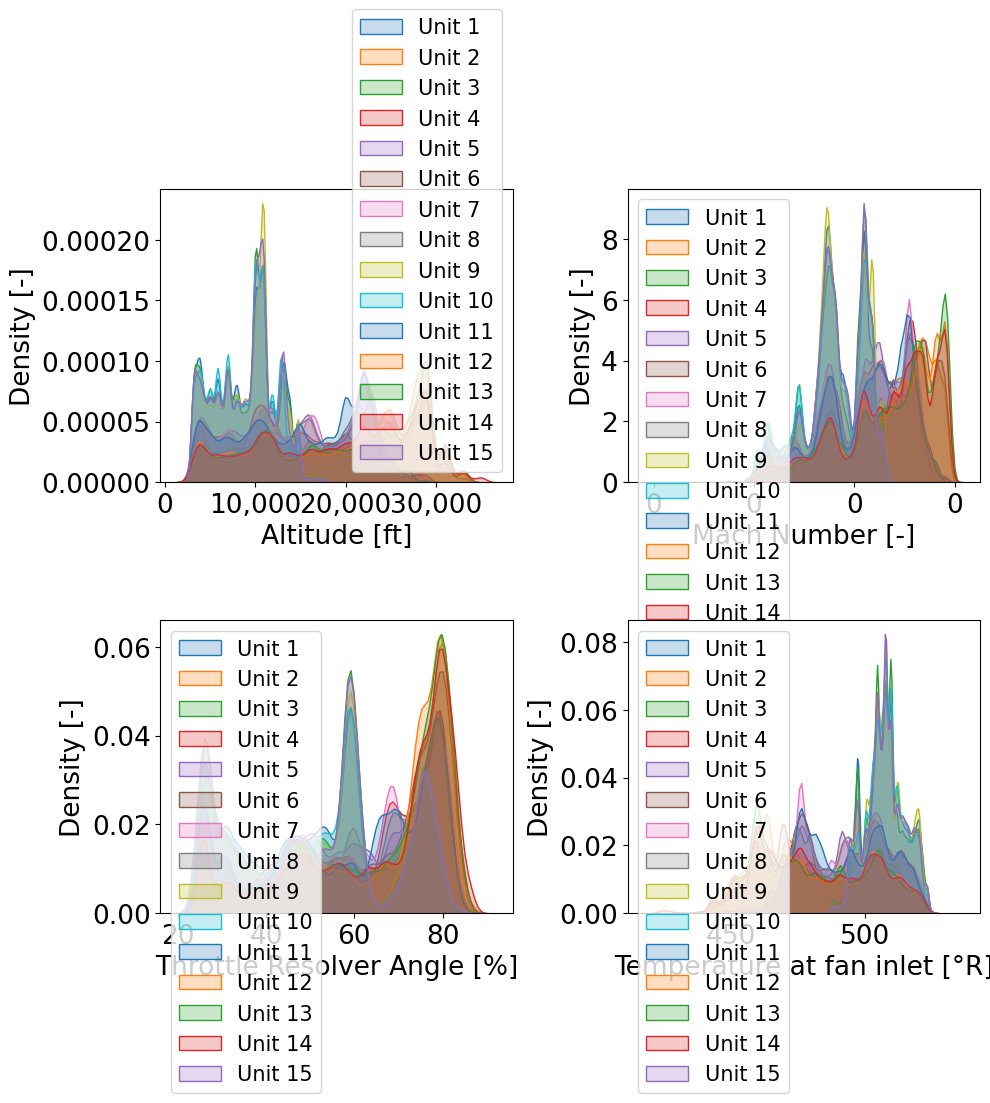

In [15]:
variables = ['alt', 'Mach', 'TRA', 'T2']
labels = ['Altitude [ft]', 'Mach Number [-]', 'Throttle Resolver Angle [%]', 'Temperature at fan inlet [°R]']
size = 10

units = list(np.unique(df_A['unit']))
leg = ['Unit ' + str(int(u)) for u in units]

plot_kde(leg, variables, labels, size, units, df_W, df_A, labelsize=19, name='kde_DS08a.png')

In [16]:
df_T = DataFrame(data=T, columns=T_var) 
df_T['unit'] = df_A['unit'].values
df_T['cycle'] = df_A['cycle'].values
df_Ts = df_T.drop_duplicates()
df_Ts.describe()

,fan_eff_mod,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod,unit,cycle
count,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000
mean,-0.002430,-0.003739,-0.003182,-0.003652,-0.002126,-0.003170,-0.002041,-0.003062,-0.002398,-0.003174,7.979879,34.541247
std,0.003202,0.006036,0.005837,0.005515,0.002476,0.004233,0.002246,0.004494,0.003307,0.004273,4.270039,20.784726
min,-0.027946,-0.053107,-0.061343,-0.046187,-0.025540,-0.035956,-0.015539,-0.038908,-0.029957,-0.039019,1.000000,1.000000
25%,-0.002667,-0.004023,-0.002880,-0.004067,-0.002485,-0.003730,-0.002397,-0.003546,-0.002496,-0.003687,4.000000,17.000000
50%,-0.001284,-0.001447,-0.001472,-0.001517,-0.001301,-0.001470,-0.001227,-0.001411,-0.001417,-0.001537,8.000000,34.000000
75%,-0.000826,-0.000813,-0.000930,-0.000892,-0.000828,-0.000973,-0.000778,-0.000780,-0.000955,-0.000909,11.000000,50.000000
max,0.000012,-0.000003,-0.000021,0.000128,0.000142,-0.000006,-0.000035,0.000110,0.000017,-0.000079,15.000000,95.000000


<Figure size 640x480 with 0 Axes>

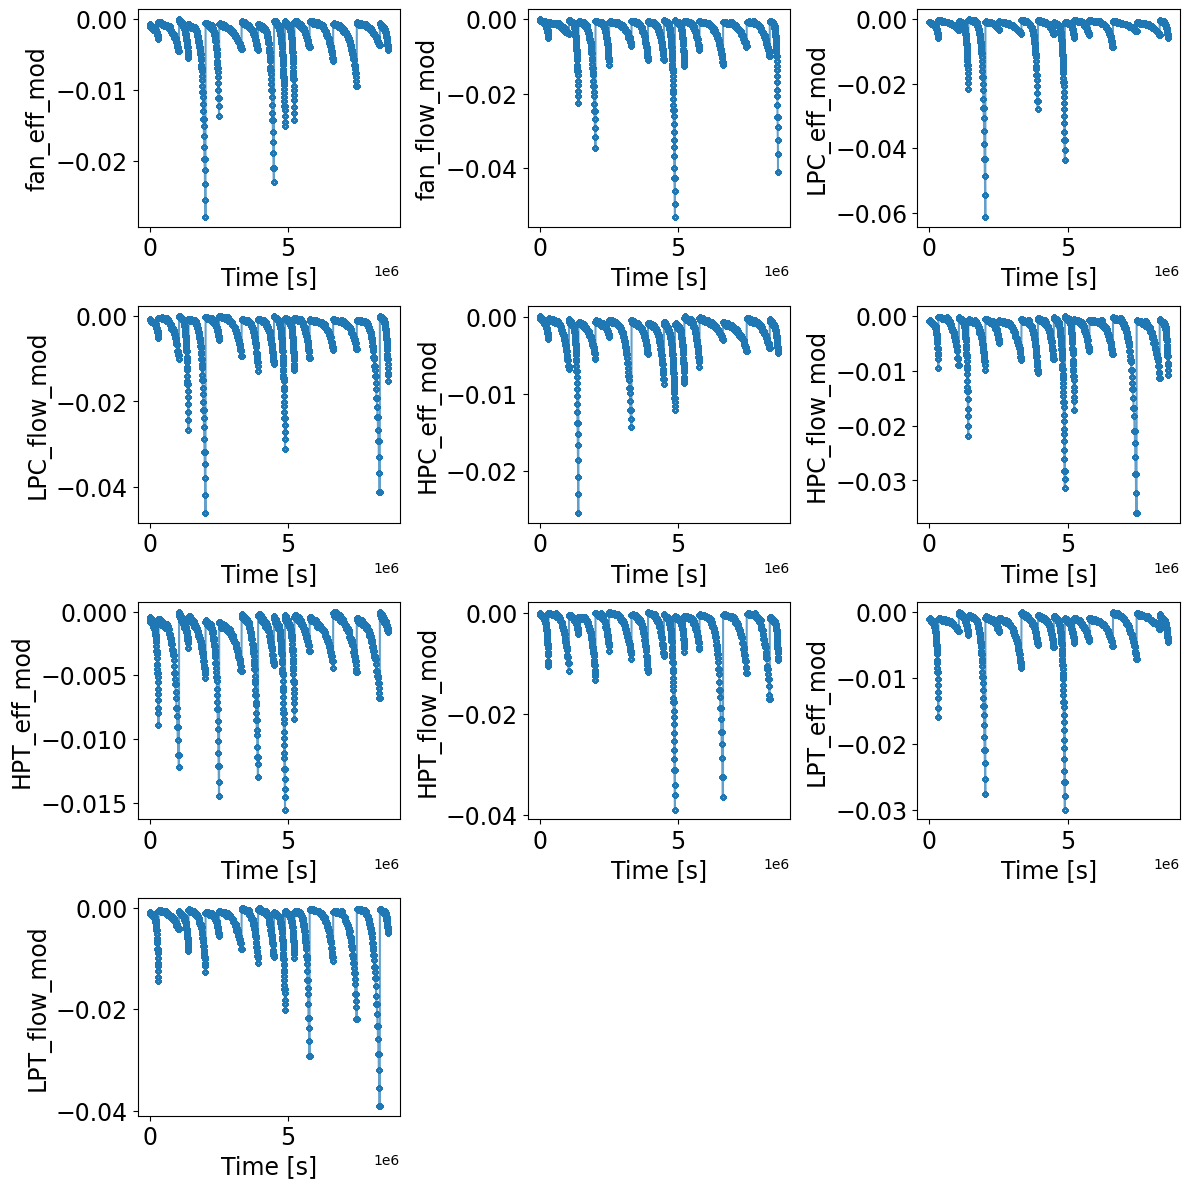

In [17]:
labels = T_var
plot_df_single_color(df_T, T_var , labels)

<Figure size 640x480 with 0 Axes>

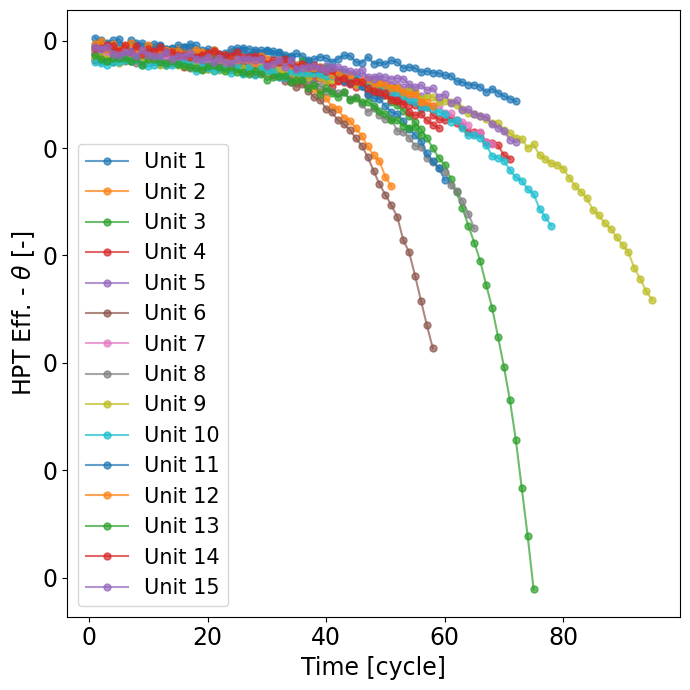

In [18]:
plot_df_color_per_unit(df_Ts, ['HPC_eff_mod'], [r'HPT Eff. - $\theta$ [-]'], size=7,  option='cycle')

In [19]:
df_X_s = DataFrame(data=X_s, columns=X_s_var) 

<Figure size 640x480 with 0 Axes>

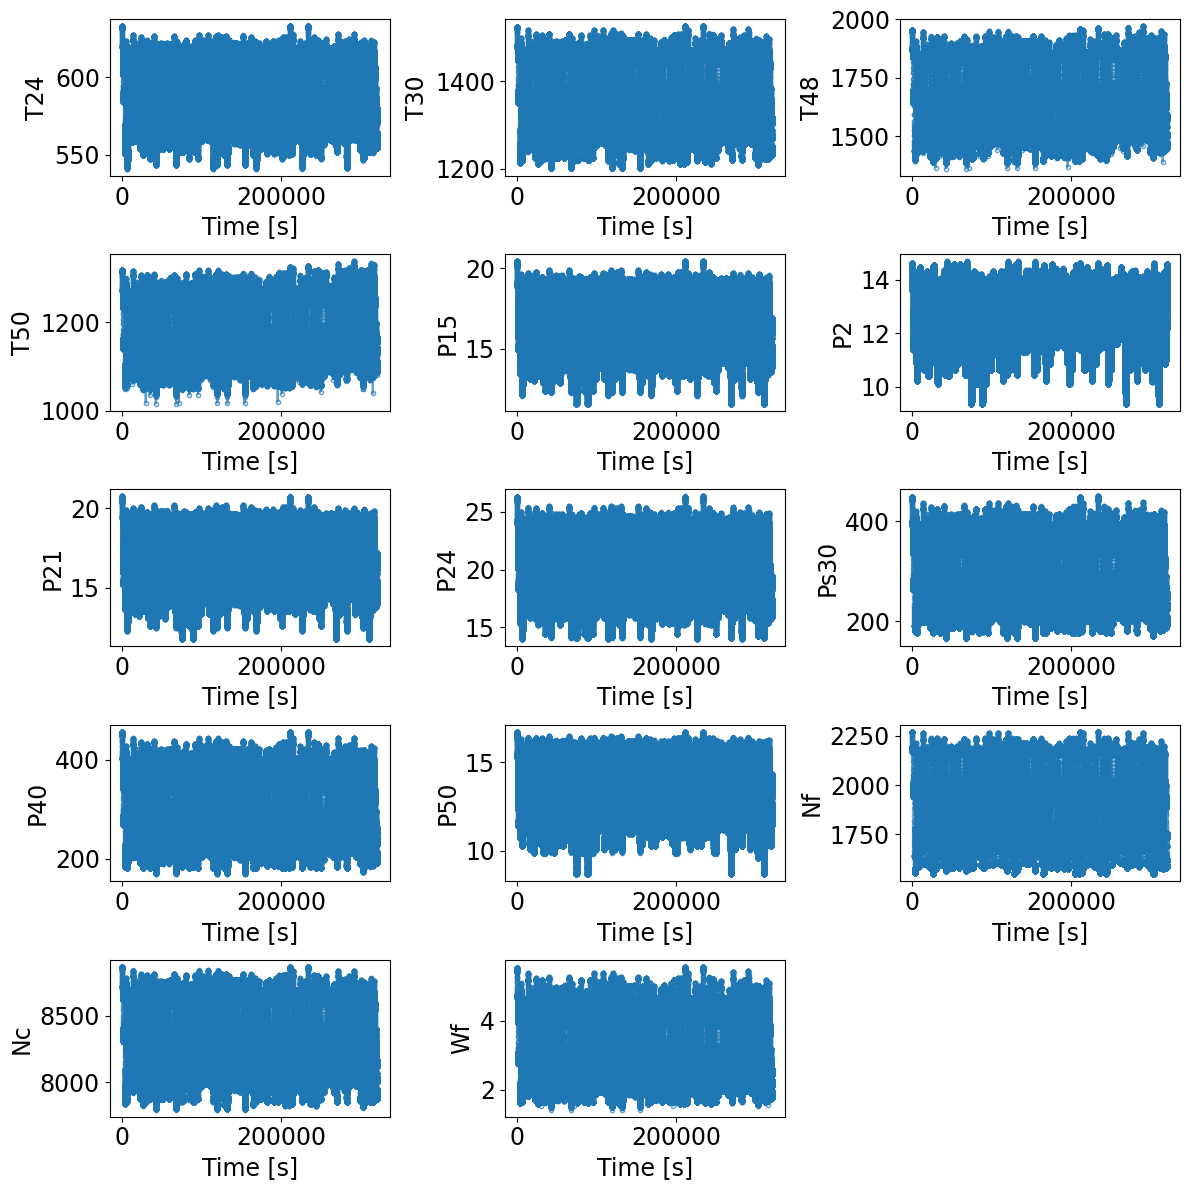

In [20]:
df_X_s_u = df_X_s.loc[df_A.unit == 1]
df_X_s_u.reset_index(inplace=True, drop=True)
labels = X_s_var
plot_df_single_color(df_X_s_u, X_s_var, labels)

<Figure size 640x480 with 0 Axes>

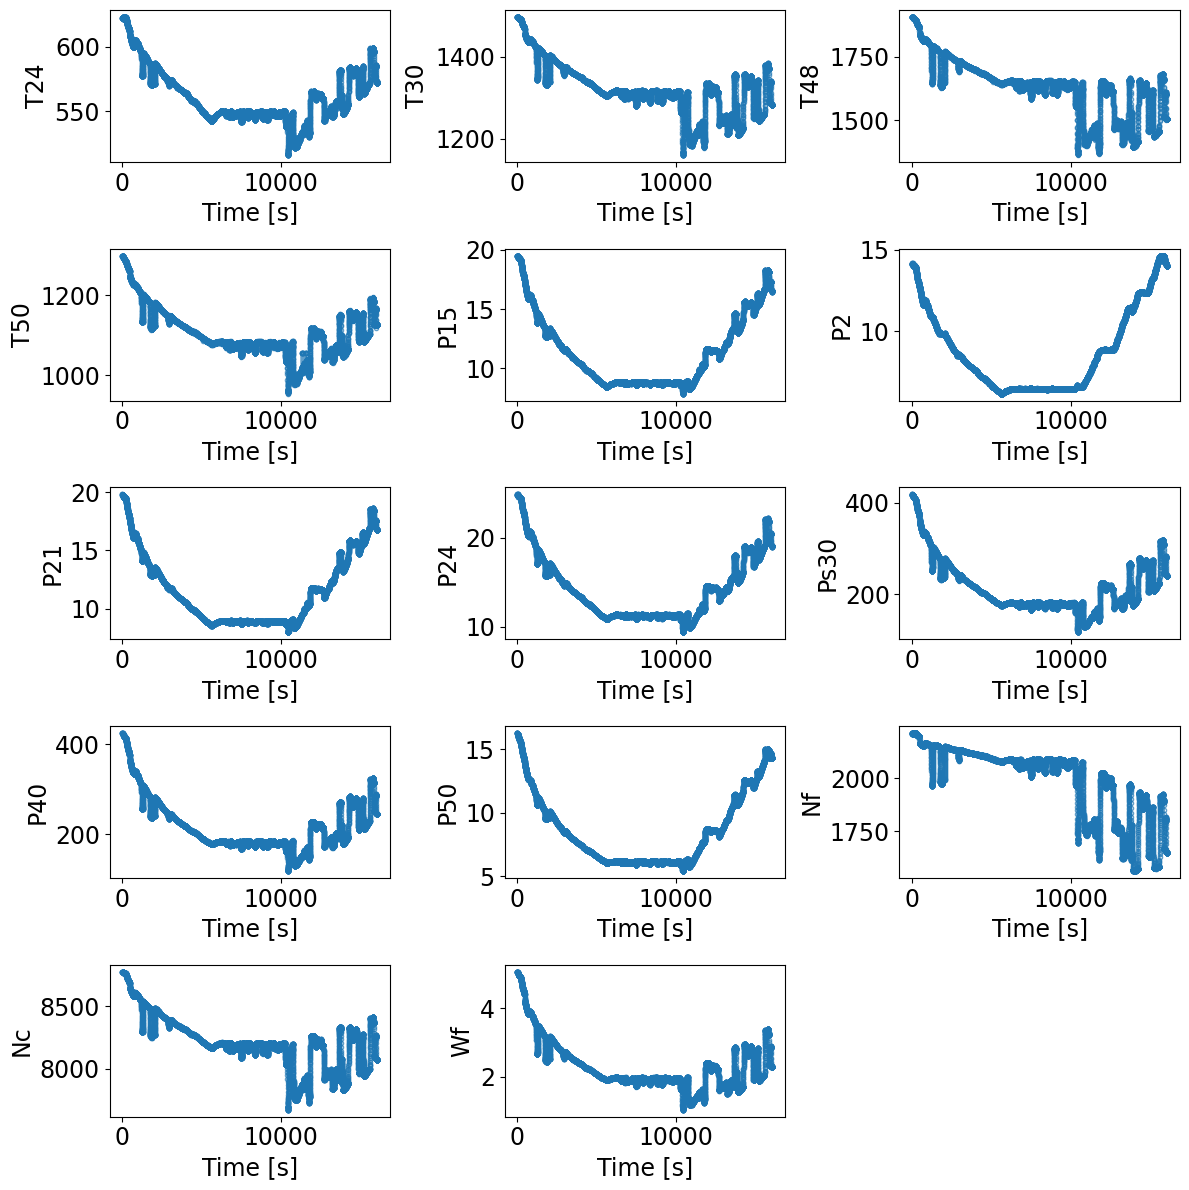

In [21]:
df_X_s_u_c = df_X_s.loc[(df_A.unit == 2) & (df_A.cycle == 1)]
df_X_s_u_c.reset_index(inplace=True, drop=True)
plot_df_single_color(df_X_s_u_c, X_s_var, X_s_var)

In [22]:
df_X_v = DataFrame(data=X_v, columns=X_v_var) 

<Figure size 640x480 with 0 Axes>

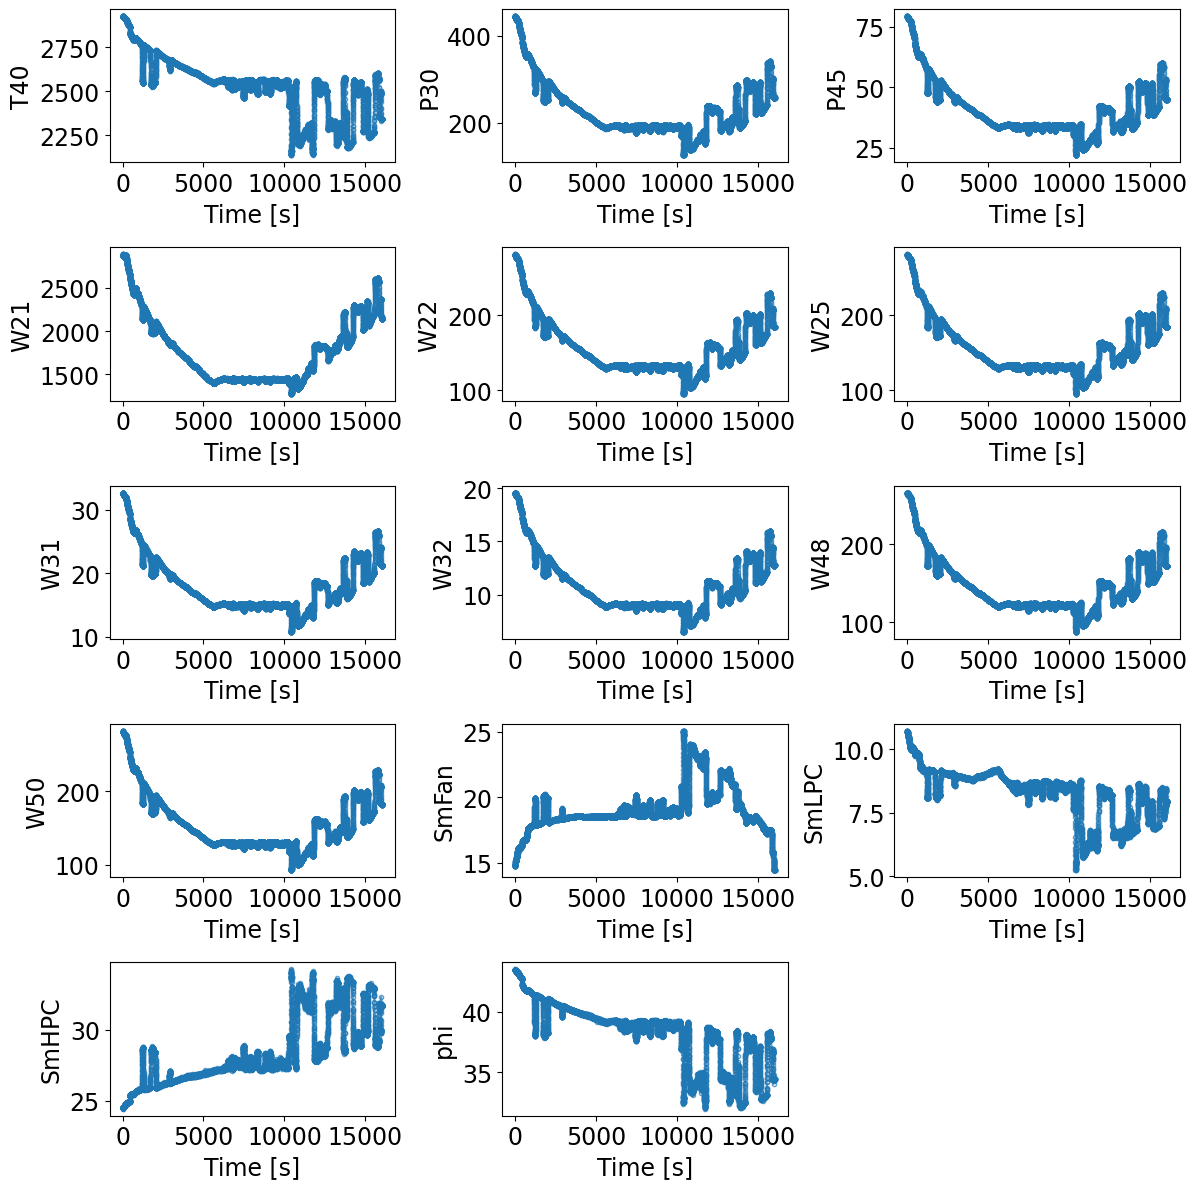

In [23]:
df_X_v_u_c = df_X_v.loc[(df_A.unit == 2) & (df_A.cycle == 1)]
df_X_v_u_c.reset_index(inplace=True, drop=True)
plot_df_single_color(df_X_v_u_c, X_v_var, X_v_var)

<Figure size 640x480 with 0 Axes>

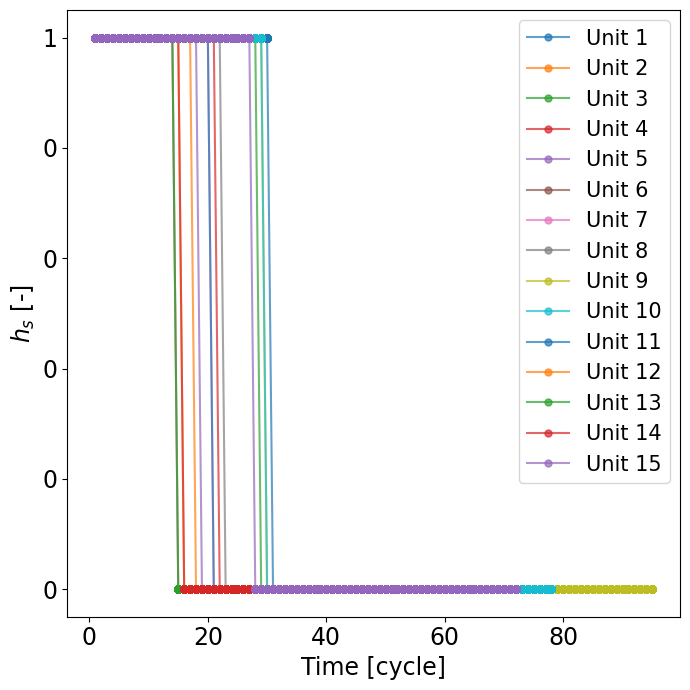

In [24]:
plot_df_color_per_unit(df_A, ['hs'], [r'$h_s$ [-]'], option='cycle')

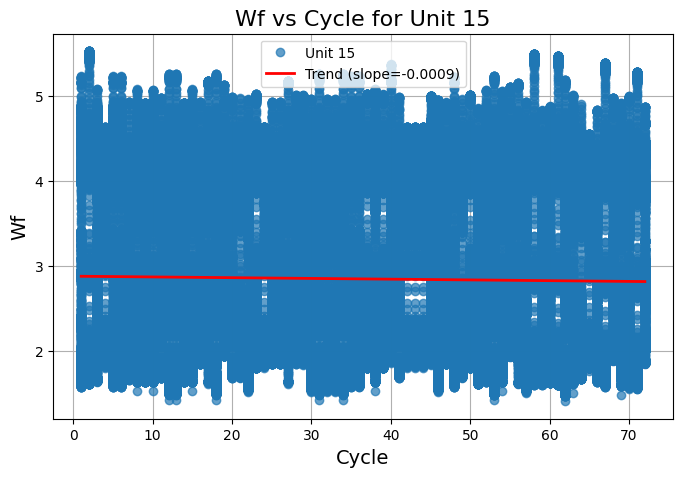

In [29]:
# Plot Wf vs cycles for unit 15 with a linear trend line
unit = 15
mask = df_A['unit'] == unit
cycles = df_A.loc[mask, 'cycle'].values
Wf = df_X_s.loc[mask, 'Wf'].values

# convert and sort by cycle
cycles = np.array(cycles, dtype=float)
Wf = np.array(Wf, dtype=float)
order = np.argsort(cycles)
cycles_s = cycles[order]
Wf_s = Wf[order]

plt.figure(figsize=(8,5))
plt.plot(cycles_s, Wf_s, 'o', alpha=0.7, label=f'Unit {unit}')
m, b = np.polyfit(cycles_s, Wf_s, 1)
plt.plot(cycles_s, m*cycles_s + b, '-', color='red', linewidth=2, label=f'Trend (slope={m:.4f})')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Wf', fontsize=14)
plt.title(f'Wf vs Cycle for Unit {unit}', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Proportion T50 / Wf across cycles for unit 15
mask = df_A['unit'] == 15
cycles = df_A.loc[mask, 'cycle'].astype(int).values
df_ratio = pd.DataFrame({
    'cycle': cycles,
    'T50': df_X_s.loc[mask, 'T50'].values,
    'Wf': df_X_s.loc[mask, 'Wf'].values
})
res = df_ratio.groupby('cycle').mean()
res['T50_div_Wf'] = res['T50'] / res['Wf']
print(res[['T50', 'Wf', 'T50_div_Wf']].round(6))

               T50        Wf  T50_div_Wf
cycle                                   
1      1152.572790  2.883262  399.746167
2      1153.032202  2.927886  393.810451
3      1149.486235  2.752949  417.547256
4      1157.601289  2.953422  391.952509
5      1153.013437  2.884128  399.778847
...            ...       ...         ...
68     1164.511607  2.927559  397.775579
69     1149.688558  2.756346  417.106069
70     1145.291416  2.705045  423.390816
71     1151.464114  2.805458  410.437133
72     1161.552851  2.870685  404.625697

[72 rows x 3 columns]


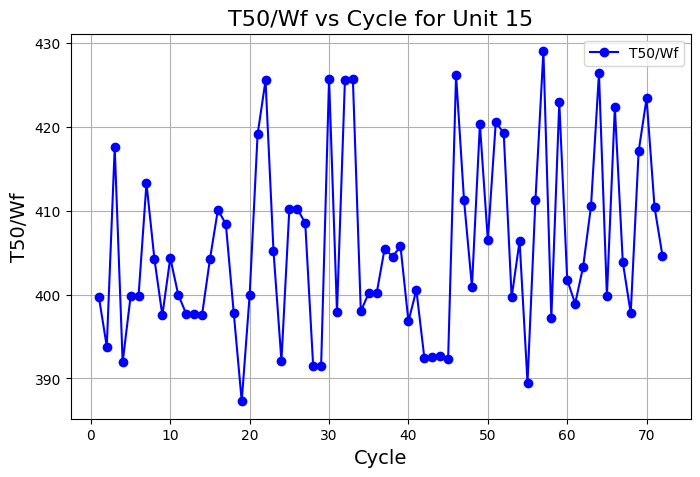

In [31]:
#Make a plot of T50/Wf vs cycle for unit 15
plt.figure(figsize=(8,5))
plt.plot(res.index, res['T50_div_Wf'], 'o-', color='blue', label='T50/Wf')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('T50/Wf', fontsize=14)
plt.title('T50/Wf vs Cycle for Unit 15', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

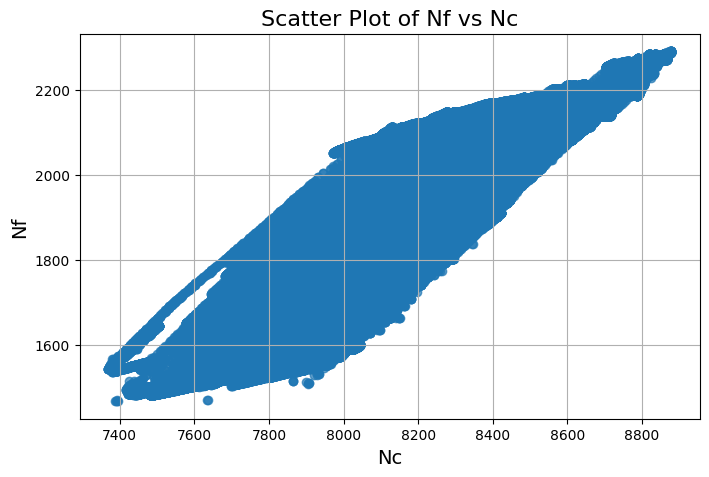

In [34]:
#Make a scatter plot of Nf vs Nc 
plt.figure(figsize=(8,5))
plt.scatter(df_X_s['Nc'], df_X_s['Nf'], alpha=0.7)
plt.xlabel('Nc', fontsize=14)
plt.ylabel('Nf', fontsize=14)
plt.title('Scatter Plot of Nf vs Nc', fontsize=16)
plt.grid(True)
plt.show()

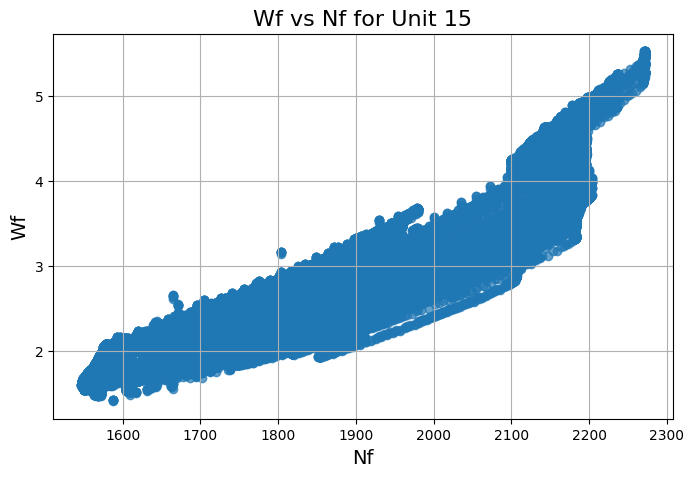

In [35]:
#Make a plot showing the tendency of Wf vs Nf accross unit 15
mask = df_A['unit'] == 15
plt.figure(figsize=(8,5))
plt.scatter(df_X_s.loc[mask, 'Nf'], df_X_s.loc[mask, 'Wf'], alpha=0.7)
plt.xlabel('Nf', fontsize=14)
plt.ylabel('Wf', fontsize=14)
plt.title('Wf vs Nf for Unit 15', fontsize=16)
plt.grid(True)
plt.show()

In [47]:
# ==========================================
# 2. PREPROCESAMIENTO
# ==========================================

# Concatenar todas las variables para formar la matriz de características X
# Usamos W (condiciones), Xs (sensores reales) y Xv (virtuales)
X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)

# Escalado Min-Max Global (-1 a 1)
# Importante: Fit solo en Train para evitar data leakage
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Forma de X_train: {X_train_scaled.shape}")
print(f"Forma de X_test: {X_test_scaled.shape}")

NameError: name 'train_W' is not defined